In [1]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

from scripts.readTdi import readTdi, getTdiPath
from psd_estimation_methods.wosa import wosa
from scripts.psdNoise import time_noise_from_psd, n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
from scripts.plot import plot_psd_noise_histogram, plot, plot_orig_and_noise_psds, plot_psd_noise_histogram_two_cross_two, draw_chi2
import scipy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2      # already used elsewhere

# ------------------------------------------------------------
def collect_psd_bias(
    nperseg_list,
    fraction,
    time_noises,
    fs,
    orig_psd,
    f_orig,
    noverlap=0,
    *,
    choose_same_freq=True
):
    """
    For each nperseg in nperseg_list:
      1. Build 'true' PSD (segment average of the original data) and
         grab the value at a chosen frequency bin.
      2. Build many noise–realisation PSDs and take the mean of the
         resulting histogram at the same bin.
      3. Record the bias  PSD_true - PSD_hist.
    Returns arrays in the same order as nperseg_list.
    """
    psd_true_arr   = []
    psd_hist_arr   = []
    chosen_freqs   = []   # optional, but handy to keep
    nseg_arr = []

    # Loop over requested segment sizes
    for nperseg in nperseg_list:
        # --- 1) PSD of the original data --------------------
        f_noise, noise_psds, nseg = n_noise_psds(
            time_noises, fs, nperseg, noverlap=noverlap
        )
        # Let the helper pick the same fraction of lowest-noise bins
        # and return the 'true' PSD value at the chosen frequency
        psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
            orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
        )

        # --- 2) Mean of the histogram of noise realisations ----
        psd_hist_mean = psd_vals.mean()

        # --- 3) Collect results -------------------------------
        psd_true_arr.append(orig_val)
        psd_hist_arr.append(psd_hist_mean)
        chosen_freqs.append(chosen_freq)
        nseg_arr.append(nseg[0])

    nperseg_arr   = np.asarray(nperseg_list, dtype=int)
    psd_true_arr  = np.asarray(psd_true_arr)
    psd_hist_arr  = np.asarray(psd_hist_arr)
    bias_arr      = psd_true_arr - psd_hist_arr       
    nseg_arr      = np.asarray(nseg_arr, dtype=int)

    return nperseg_arr, psd_true_arr, psd_hist_arr, bias_arr, chosen_freqs, nseg_arr


# ------------------------------------------------------------
def plot_psd_bias(nperseg_arr, bias_arr, *, ax=None):
    """
    Scatter-plot of bias (PSD_true - PSD_hist) versus nperseg.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.scatter(nperseg_arr, bias_arr, s=60, marker='o')
    ax.set_xlabel("nperseg (samples)")
    ax.set_ylabel(r"$\mathrm{PSD}_{\mathrm{true}} - \mathrm{PSD}_{\mathrm{hist}}$")
    ax.set_title("Bias of PSD estimate vs. segment length")
    ax.grid(True)
    plt.tight_layout()
    return ax

def plot_bias_vs_segments(nseg_arr, bias_arr, *, tick_step=1, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.scatter(nseg_arr, bias_arr, s=60)

    ax.set_xlabel("nseg (number of segments)")
    ax.set_ylabel(r"$\mathrm{PSD}_{\mathrm{true}} - \mathrm{PSD}_{\mathrm{hist}}$")
    ax.set_title("Bias of PSD estimate vs. number of segments")
    ax.grid(True)

    # ----- customise ticks here -----
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(tick_step))
    ax.set_xlim(nseg_arr.min()-1, nseg_arr.max()+1)
    # --------------------------------

    plt.tight_layout()
    return ax

# ------------------------------------------------------------

# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data_orig, fs, t = readTdi(tdi_path)
nperseg = 20000

f_orig, orig_psd = scipy.signal.welch(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 


In [3]:
data_orig.size

200000

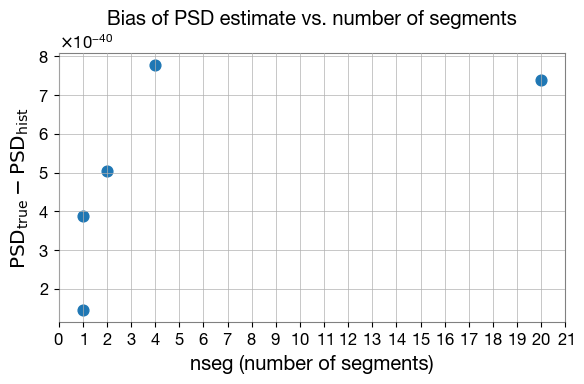

In [4]:
nperseg_list = [20000, 13000, 10000, 5000, 1000]
# nperseg_list = np.arange(20_000, 999, -1_000)
fraction     = 0.8

time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

(nperseg_arr,
 psd_true_arr,
 psd_hist_arr,
 bias_arr,
 freqs_used,
 nseg_arr) = collect_psd_bias(
     nperseg_list,
     fraction,
     time_noises = time_noises,
     fs          = fs,
     orig_psd    = orig_psd,
     f_orig      = f_orig,
     noverlap    = 0
 )

plot_bias_vs_segments(nseg_arr, bias_arr)
plt.show()

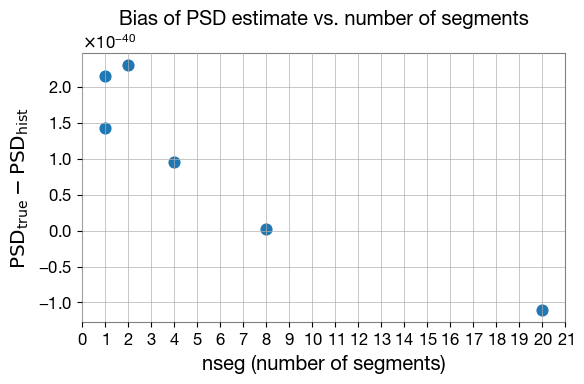

In [5]:
nperseg_list = [20000, 15000, 10000, 5000, 2500, 1000]
# nperseg_list = np.arange(20_000, 999, -1_000)
fraction     = 0.7

time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

(nperseg_arr,
 psd_true_arr,
 psd_hist_arr,
 bias_arr,
 freqs_used,
 nseg_arr) = collect_psd_bias(
     nperseg_list,
     fraction,
     time_noises = time_noises,
     fs          = fs,
     orig_psd    = orig_psd,
     f_orig      = f_orig,
     noverlap    = 0
 )

plot_bias_vs_segments(nseg_arr, bias_arr)
plt.show()

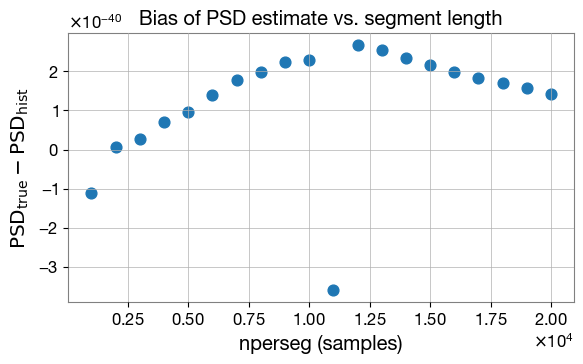

In [6]:
nperseg_list = np.arange(20_000, 999, -1_000)
fraction     = 0.7

time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

(nperseg_arr,
 psd_true_arr,
 psd_hist_arr,
 bias_arr,
 freqs_used,
 seg_counts) = collect_psd_bias(
     nperseg_list,
     fraction,
     time_noises=time_noises,
     fs=fs,
     orig_psd=orig_psd,
     f_orig=f_orig,
     noverlap=0
 )

# quick visual
plot_psd_bias(nperseg_arr, bias_arr)
plt.show()

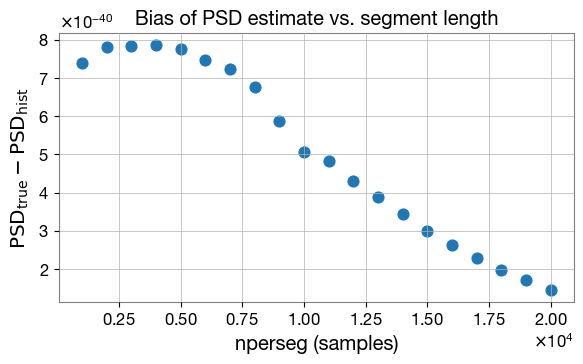

In [7]:
nperseg_list = np.arange(20_000, 999, -1_000)
fraction     = 0.8

time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

(nperseg_arr,
 psd_true_arr,
 psd_hist_arr,
 bias_arr,
 freqs_used,
 seg_counts) = collect_psd_bias(
     nperseg_list,
     fraction,
     time_noises=time_noises,
     fs=fs,
     orig_psd=orig_psd,
     f_orig=f_orig,
     noverlap=0
 )

# quick visual
plot_psd_bias(nperseg_arr, bias_arr)
plt.show()

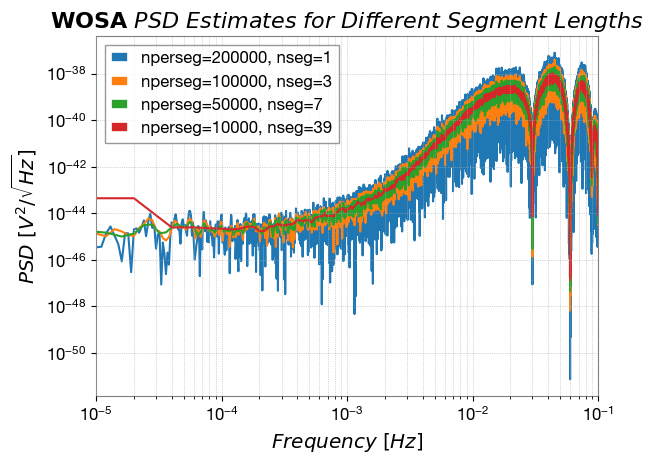

In [8]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data_orig, fs, t = readTdi(tdi_path)
nperseg_array = [200000, 100000, 50000, 10000]
psd_wosa_list = []
f_wosa_list = []
nseg_list = []

# Loop over each nperseg value
for nperseg in nperseg_array:
    f_wosa, psd_wosa, _, nseg = wosa(
        x=data_orig,
        fs=fs,
        nperseg=nperseg
    )
    f_wosa_list.append(f_wosa)
    psd_wosa_list.append(psd_wosa)
    nseg_list.append(nseg[0])

# Plotting
fig, ax = plt.subplots()

# Plot each WOSA PSD with label
for nperseg, f_wosa, psd_wosa, nseg in zip(nperseg_array, f_wosa_list, psd_wosa_list, nseg_list):
    ax.plot(f_wosa, psd_wosa, label=f'nperseg={nperseg}, nseg={nseg}')

# Cosmetics
ax.set_xlim(fs/20000, fs/2)  # adjust x-limits as needed
ax.set_xlabel(r"$Frequency \ [Hz]$")
ax.set_ylabel(r"$PSD \ [V^2/\sqrt{Hz}]$")
plt.title(r"$\mathbf{WOSA}\ PSD\ Estimates\ for\ Different\ Segment\ Lengths$", fontsize=16)

ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', ls=':', lw=0.5)
ax.legend()
fig.tight_layout()
plt.show()


In [9]:
data_orig.shape

(200000,)

In [10]:
# figuring out how much wider is the median distribution as compared to the mean distribution 
from scipy.signal import savgol_filter

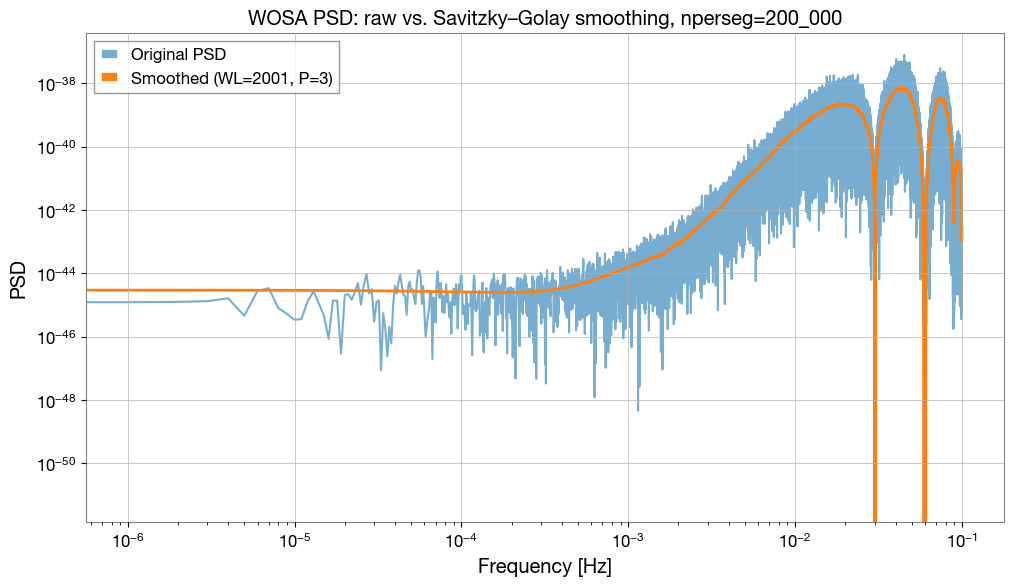

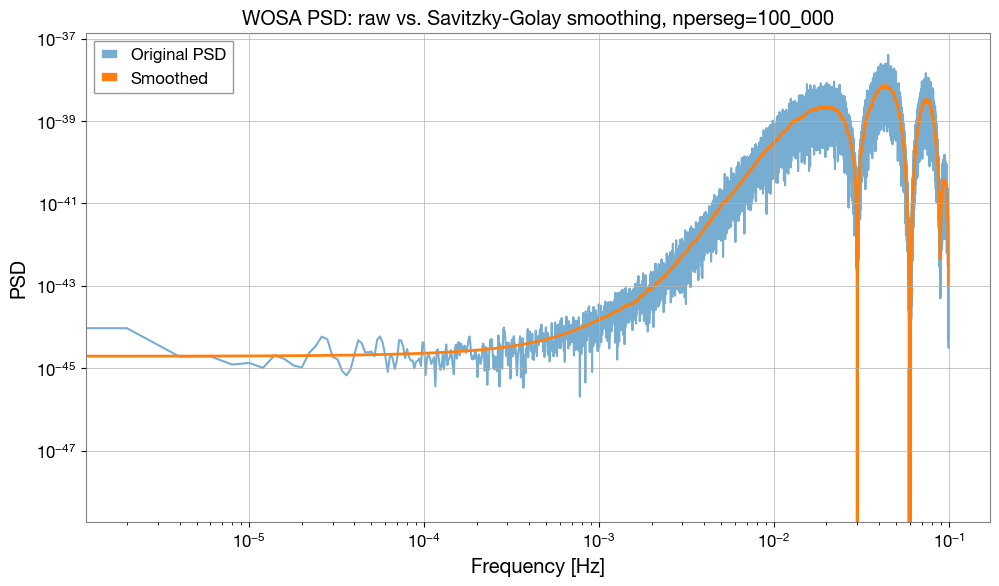

In [11]:
nperseg = 200_000
f_wosa, psd_wosa, _, nseg = wosa(
        x=data_orig,
        fs=fs,
        nperseg=nperseg
)

window_length = 2001   # e.g. smooth over ~100 bins
polyorder    =   3  
psd_smooth = savgol_filter(psd_wosa, window_length=window_length, polyorder=polyorder)

plt.figure(figsize=(10, 6))
plt.plot(f_wosa, psd_wosa,   label='Original PSD', alpha=0.6)
plt.plot(f_wosa, psd_smooth, label=f'Smoothed (WL={window_length}, P={polyorder})', linewidth=2)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD')
plt.legend()
plt.title('WOSA PSD: raw vs. Savitzky–Golay smoothing, nperseg=200_000')
plt.tight_layout()
plt.loglog()
plt.show()


nperseg = 100_000
f_wosa_2, psd_wosa_2, _, nseg = wosa(
        x=data_orig,
        fs=fs,
        nperseg=nperseg
)

window_length = 1001   # e.g. smooth over ~100 bins
polyorder    =   3  
psd_smooth_2 = savgol_filter(psd_wosa_2, window_length=window_length, polyorder=polyorder)

plt.figure(figsize=(10, 6))
plt.plot(f_wosa_2, psd_wosa_2,   label='Original PSD', alpha=0.6)
plt.plot(f_wosa_2, psd_smooth_2, label=f'Smoothed', linewidth=2)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD')
plt.legend()
plt.title('WOSA PSD: raw vs. Savitzky-Golay smoothing, nperseg=100_000')
plt.tight_layout()
plt.loglog()
plt.show()

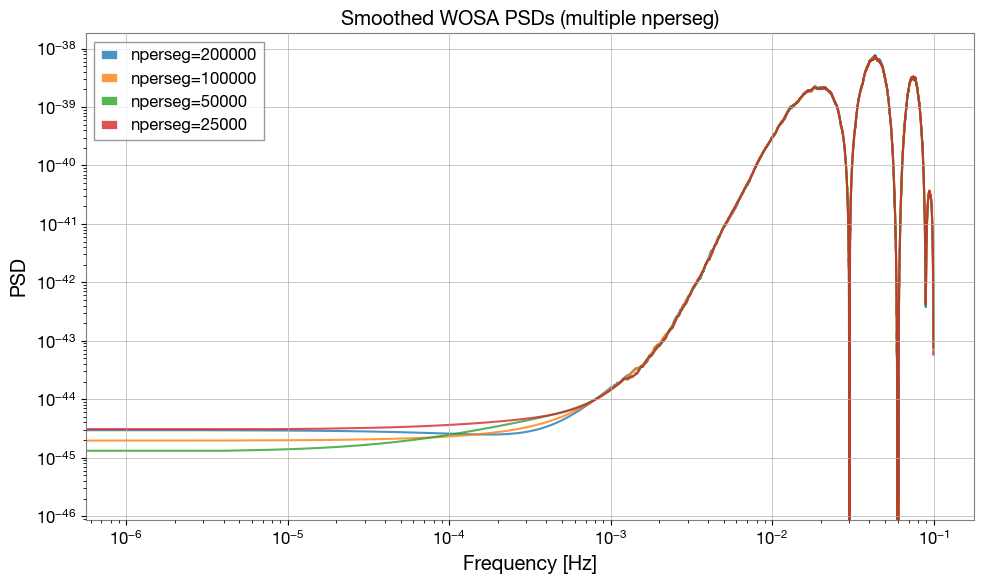

In [12]:
# pick any number of segment sizes and matching SavGol windows
nper_list = [200_000, 100_000, 50_000, 25_000]
wl_list   = [2001,     1001,     601,    301]     # each window length must be odd

if len(nper_list) != len(wl_list):
    raise ValueError("nper_list and wl_list must have the same length")

plt.figure(figsize=(10, 6))

for nper, wl in zip(nper_list, wl_list):
    if wl % 2 == 0:          # force window length to be odd
        wl += 1

    f, psd, _, _ = wosa(x=data_orig, fs=fs, nperseg=nper)
    psd_smooth = savgol_filter(psd, wl, 3)
    plt.plot(f, psd_smooth, label=f"nperseg={nper}", alpha=0.8)

plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.title("Smoothed WOSA PSDs (multiple nperseg)")
plt.legend()
plt.loglog()          # log x- and y-axes
# plt.semilogx()
plt.tight_layout()
plt.show()

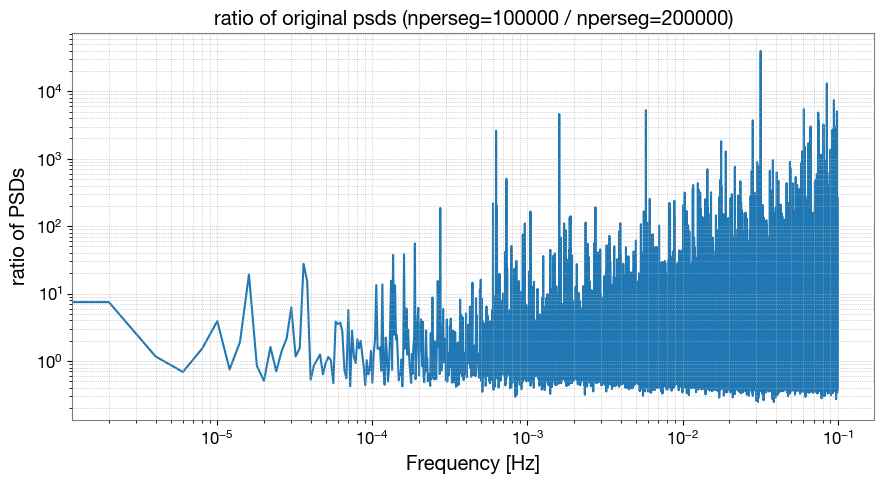

In [13]:
nper_big   = 200_000
nper_small = 100_000

f_big,   psd_big,   _, _ = wosa(x=data_orig, fs=fs, nperseg=nper_big)
f_small, psd_small, _, _ = wosa(x=data_orig, fs=fs, nperseg=nper_small)

if nper_big % nper_small:
    raise ValueError("nper_big / nper_small must be an integer")

step = nper_big // nper_small
psd_big_aligned = psd_big[::step][:len(f_small)]

# keep only points where both PSDs are strictly positive
mask   = (psd_big_aligned > 0) & (psd_small > 0)
f_use  = f_small[mask]
ratio  = psd_small[mask] / psd_big_aligned[mask]

plt.figure(figsize=(9, 5))
plt.loglog(f_use, ratio)
# plt.semilogx(f_use, ratio)
plt.xlabel('Frequency [Hz]')
plt.ylabel(f'ratio of PSDs')
plt.title(f'ratio of original psds (nperseg={nper_small} / nperseg={nper_big})')
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

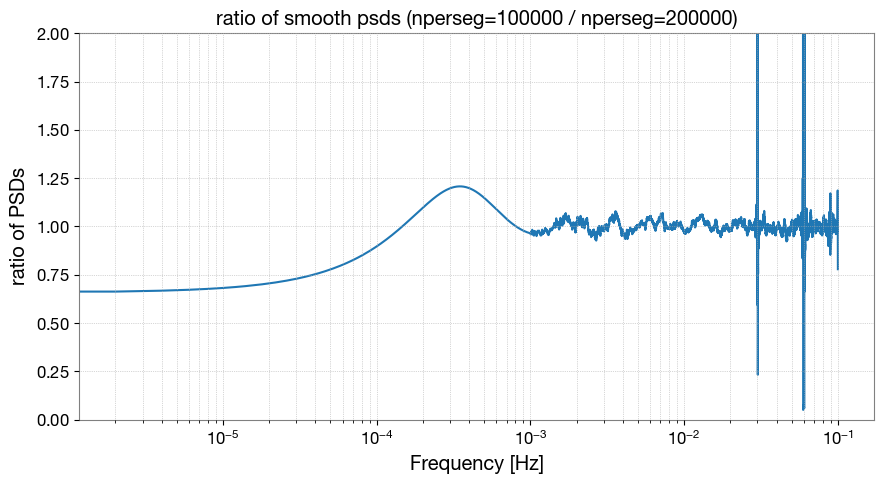

In [14]:
nper_big   = 200_000
f_big,   psd_big,   _, _ = wosa(x=data_orig, fs=fs, nperseg=nper_big)
window_length = 2001   
polyorder    =   3  
psd_big = savgol_filter(psd_big, window_length=window_length, polyorder=polyorder)

nper_small = 100_000
f_small, psd_small, _, _ = wosa(x=data_orig, fs=fs, nperseg=nper_small)
window_length = 1001  
polyorder    =   3
psd_small = savgol_filter(psd_small, window_length=window_length, polyorder=polyorder)

if nper_big % nper_small:
    raise ValueError("nper_big / nper_small must be an integer")

step = nper_big // nper_small
psd_big_aligned = psd_big[::step][:len(f_small)]

# keep only points where both PSDs are strictly positive
mask   = (psd_big_aligned > 0) & (psd_small > 0)
f_use  = f_small[mask]
ratio  = psd_small[mask] / psd_big_aligned[mask]

plt.figure(figsize=(9, 5))
# plt.loglog(f_use, ratio)
plt.semilogx(f_use, ratio)
plt.xlabel('Frequency [Hz]')
plt.ylabel(f'ratio of PSDs')
plt.ylim(0,2)
plt.title(f'ratio of smooth psds (nperseg={nper_small} / nperseg={nper_big})')
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

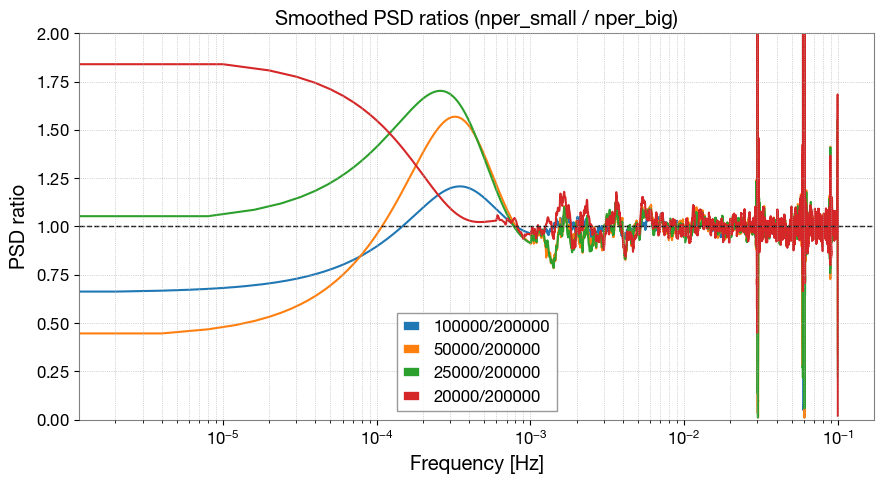

In [15]:
# reference (finest-resolution) PSD
nper_big = 200_000
f_big, psd_big, _, _ = wosa(x=data_orig, fs=fs, nperseg=nper_big)
psd_big = savgol_filter(psd_big, 2001, 3)          # smooth once

# choose the smaller segment sizes and their *own* SavGol window lengths
small_list = [100_000,  50_000,  25_000, 20_000]
wl_list    = [1001,       601,     301, 121]     # each must be odd

if len(small_list) != len(wl_list):
    raise ValueError("small_list and wl_list sizes differ")

plt.figure(figsize=(9, 5))

for nper_small, wl in zip(small_list, wl_list):
    if nper_big % nper_small:
        raise ValueError(f"{nper_big}/{nper_small} not an integer")
    if wl % 2 == 0:                 # force odd
        wl += 1

    f_s, psd_s, _, _ = wosa(x=data_orig, fs=fs, nperseg=nper_small)
    psd_s = savgol_filter(psd_s, wl, 3)

    step = nper_big // nper_small
    psd_big_aligned = psd_big[::step][:len(psd_s)]

    mask  = (psd_big_aligned > 0) & (psd_s > 0)
    ratio = psd_s[mask] / psd_big_aligned[mask]
    plt.semilogx(f_s[mask], ratio, label=f"{nper_small}/{nper_big}")

plt.axhline(1, color='k', linestyle='--', linewidth=1)  # horizontal line y = 1
plt.ylim(0, 2)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD ratio")
plt.title("Smoothed PSD ratios (nper_small / nper_big)")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()
plt.show()

## Using piece-wise smoothing

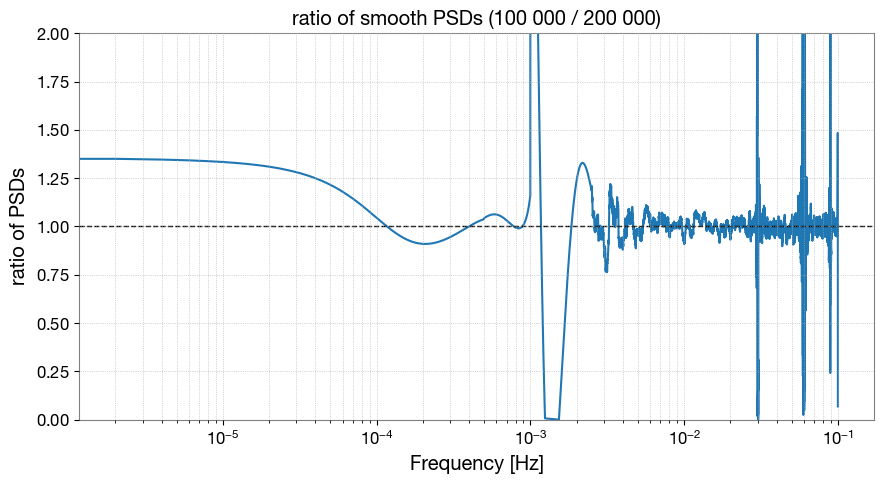

In [16]:
nper_big   = 200_000
f_big, psd_big, _, _ = wosa(x=data_orig, fs=fs, nperseg=nper_big)

nper_small = 100_000
f_small, psd_small, _, _ = wosa(x=data_orig, fs=fs, nperseg=nper_small)

cut_freq = 1e-3
win_big_lo,  win_big_hi  = 2001, 3001
win_small_lo, win_small_hi = 1001, 2001
poly = 5

def safe_win(w, n, order):
    w = min(w, n)
    if w % 2 == 0: w -= 1
    if w < order + 2: w = order + 2 | 1
    return w

def sg_piecewise(freq, psd, w_lo, w_hi, cut, order):
    idx = np.searchsorted(freq, cut)
    out = np.empty_like(psd)
    w_lo = safe_win(w_lo, idx,           order)
    w_hi = safe_win(w_hi, len(psd)-idx,  order)
    out[:idx]  = savgol_filter(psd[:idx],  w_lo, order, mode="interp") if idx else psd[:idx]
    out[idx:]  = savgol_filter(psd[idx:], w_hi, order, mode="interp") if len(psd)-idx else psd[idx:]
    return out

psd_big_sm   = sg_piecewise(f_big,   psd_big,   win_big_lo,  win_big_hi,  cut_freq, poly)
psd_small_sm = sg_piecewise(f_small, psd_small, win_small_lo, win_small_hi, cut_freq, poly)

step = nper_big // nper_small
psd_big_aligned = psd_big_sm[::step][:len(psd_small_sm)]

mask  = (psd_big_aligned > 0) & (psd_small_sm > 0)
f_use = f_small[mask]
ratio = psd_small_sm[mask] / psd_big_aligned[mask]

plt.figure(figsize=(9, 5))
plt.semilogx(f_use, ratio)
plt.axhline(1, color="k", ls="--", lw=1)
plt.ylim(0, 2)
plt.xlabel("Frequency [Hz]")
plt.ylabel("ratio of PSDs")
plt.title("ratio of smooth PSDs (100 000 / 200 000)")
plt.grid(True, which="both", ls=":")
plt.tight_layout()
plt.show()

## Smooth PSD 

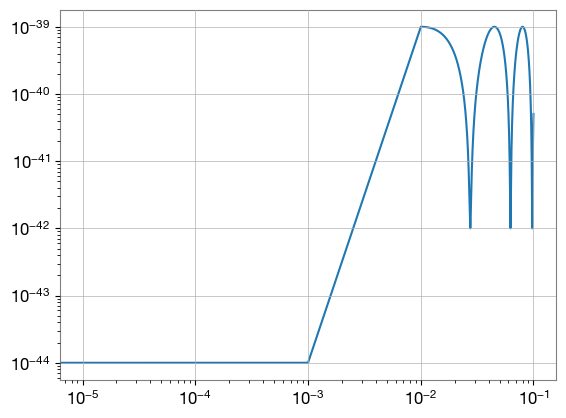

In [17]:
x = np.linspace(0, 0.1, 10000)
psd_true = np.zeros_like(x)

# Anchors
x1, x2 = 1e-3, 1e-2
y1, y2 = 1e-44, 1e-39

# Region 1: flat at 1e-44
psd_true[x <= x1] = y1

# Region 2: power-law so it's exactly straight on log-log
mask2 = (x > x1) & (x <= x2)
alpha = np.log10(y2/y1) / np.log10(x2/x1)   # = 5 here
psd_true[mask2] = y1 * (x[mask2]/x1)**alpha

# Region 3 baseline: flat at 1e-39
mask3 = x > x2
psd_true[mask3] = y2

# Add sine-squared notches (always positive, gives dips only)
depth  = 0.999     # 0..1, how deep the dips go (1 -> to ~0)
spacing = 0.07    # set dip spacing in x-units (≈ first dips near x2+spacing/4)
phase  = 0.0      # choose so continuity at x2 (sin^2(0)=0 -> factor=1 at boundary)

mod = 1 - depth * np.sin(2*np.pi * ((x[mask3]-x2)/spacing) + phase)**2
psd_true[mask3] *= mod

# Plot
plt.plot(x, psd_true)
plt.loglog()
plt.show()

[0.000e+00 1.000e-05 2.000e-05 ... 9.998e-02 9.999e-02 1.000e-01]
(20000,)


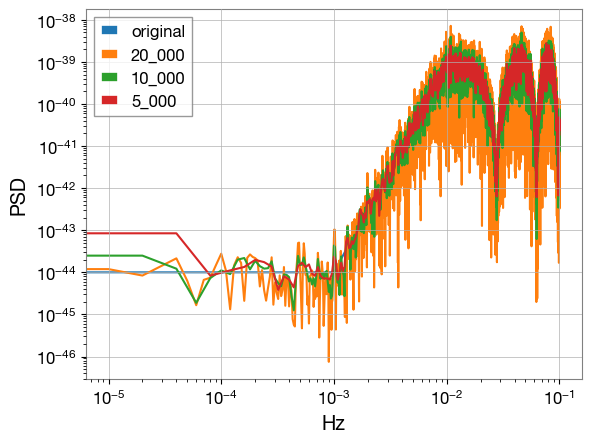

In [23]:
fs = 0.2         # fs/2 = 0.1
N  = 20000       # df = fs/N = 1e-5
f  = np.fft.rfftfreq(N, d=1/fs)   # one-sided FFT freq grid
print(f)

# build PSD
psd_true = np.zeros_like(f)

x1, x2 = 1e-3, 1e-2
y1, y2 = 1e-44, 1e-39

psd_true[f <= x1] = y1
m2 = (f > x1) & (f <= x2)
alpha = np.log10(y2/y1)/np.log10(x2/x1)  # = 5
psd_true[m2] = y1 * (f[m2]/x1)**alpha
m3 = f > x2
psd_true[m3] = y2

depth, spacing, phase = 0.999, 0.07, 0.0
mod = 1 - depth * np.sin(2*np.pi*((f[m3]-x2)/spacing) + phase)**2
psd_true[m3] *= mod
psd_true = np.maximum(psd_true, 1e-60)

# create time series such that its psd equals given psd
time_series_true = time_noise_from_psd(psd_true, fs, 20000)
print(time_series_true.shape)

# create psd-estimated by our methods
f_1, psd_1, _, _ = wosa(time_series_true, fs=fs, nperseg=20_000)
f_2, psd_2, _, _ = wosa(time_series_true, fs=fs, nperseg=10_000)
f_3, psd_3, _, _ = wosa(time_series_true, fs=fs, nperseg=5_000)

plt.loglog(f, psd_true, label='original')
plt.loglog(f_1, psd_1, label='20_000')
plt.loglog(f_2, psd_2, label='10_000')
plt.loglog(f_3, psd_3, label='5_000')
plt.legend(); plt.xlabel('Hz'); plt.ylabel('PSD'); plt.show()

[0.000e+00 1.000e-05 2.000e-05 ... 9.998e-02 9.999e-02 1.000e-01]
(10000, 20000)


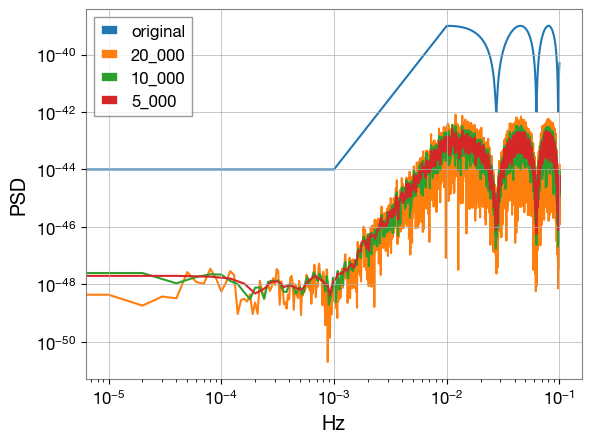

In [25]:
fs = 0.2         # fs/2 = 0.1
N  = 20000       # df = fs/N = 1e-5
f  = np.fft.rfftfreq(N, d=1/fs)   # one-sided FFT freq grid
print(f)

# build PSD
psd_true = np.zeros_like(f)

x1, x2 = 1e-3, 1e-2
y1, y2 = 1e-44, 1e-39

psd_true[f <= x1] = y1
m2 = (f > x1) & (f <= x2)
alpha = np.log10(y2/y1)/np.log10(x2/x1)  # = 5
psd_true[m2] = y1 * (f[m2]/x1)**alpha
m3 = f > x2
psd_true[m3] = y2

depth, spacing, phase = 0.999, 0.07, 0.0
mod = 1 - depth * np.sin(2*np.pi*((f[m3]-x2)/spacing) + phase)**2
psd_true[m3] *= mod
psd_true = np.maximum(psd_true, 1e-60)

# create time series such that its psd equals given psd
n_time_series_true = n_time_noise_from_psd(psd_true, fs, 20000, n=1000)
print(n_time_series_true.shape)
time_series_true = n_time_series_true.mean(axis=0)

# create psd-estimated by our methods
f_1, psd_1, _, _ = wosa(time_series_true, fs=fs, nperseg=20_000)
f_2, psd_2, _, _ = wosa(time_series_true, fs=fs, nperseg=10_000)
f_3, psd_3, _, _ = wosa(time_series_true, fs=fs, nperseg=5_000)

plt.loglog(f, psd_true, label='original')
plt.loglog(f_1, psd_1, label='20_000')
plt.loglog(f_2, psd_2, label='10_000')
plt.loglog(f_3, psd_3, label='5_000')
plt.legend(); plt.xlabel('Hz'); plt.ylabel('PSD'); plt.show()

[0.000e+00 1.000e-05 2.000e-05 ... 9.998e-02 9.999e-02 1.000e-01]
(10000, 20000)


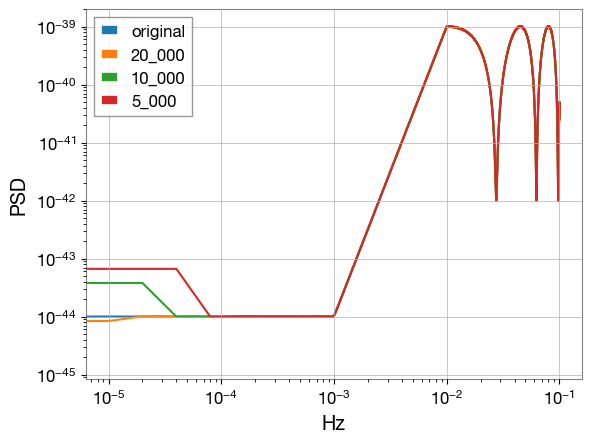

In [38]:
fs = 0.2         # fs/2 = 0.1
nperseg  = 20000       # df = fs/N = 1e-5
f  = np.fft.rfftfreq(N, d=1/fs)   # one-sided FFT freq grid
print(f)

# build PSD
psd_true = np.zeros_like(f)

x1, x2 = 1e-3, 1e-2
y1, y2 = 1e-44, 1e-39

psd_true[f <= x1] = y1
m2 = (f > x1) & (f <= x2)
alpha = np.log10(y2/y1)/np.log10(x2/x1)  # = 5
psd_true[m2] = y1 * (f[m2]/x1)**alpha
m3 = f > x2
psd_true[m3] = y2

depth, spacing, phase = 0.999, 0.07, 0.0
mod = 1 - depth * np.sin(2*np.pi*((f[m3]-x2)/spacing) + phase)**2
psd_true[m3] *= mod
psd_true = np.maximum(psd_true, 1e-60)

# psd1
time_noises = n_time_noise_from_psd(psd_true, fs, nperseg, n=10000)
print(time_noises.shape)
f_1, n_psds, _ = n_noise_psds(time_noises, fs, nperseg=20_000)
psd_1 = n_psds.mean(axis=0)

# psd2
time_noises = n_time_noise_from_psd(psd_true, fs, nperseg, n=10000)
f_2, n_psds, _ = n_noise_psds(time_noises, fs, nperseg=10_000)
psd_2 = n_psds.mean(axis=0)

# psd3
time_noises = n_time_noise_from_psd(psd_true, fs, nperseg, n=10000)
f_3, n_psds, _ = n_noise_psds(time_noises, fs, nperseg=5_000)
psd_3 = n_psds.mean(axis=0)

plt.loglog(f, psd_true, label='original')
plt.loglog(f_1, psd_1, label='20_000')
plt.loglog(f_2, psd_2, label='10_000')
plt.loglog(f_3, psd_3, label='5_000')
plt.legend(); plt.xlabel('Hz'); plt.ylabel('PSD'); plt.show()


In [39]:
print(psd_true.shape)
print(f)
print(psd_1.shape)
print(f_1)
print(psd_2.shape)
print(f_2)
print(psd_3.shape)
print(f_3)

(10001,)
[0.000e+00 1.000e-05 2.000e-05 ... 9.998e-02 9.999e-02 1.000e-01]
(10001,)
[0.000e+00 1.000e-05 2.000e-05 ... 9.998e-02 9.999e-02 1.000e-01]
(5001,)
[0.000e+00 2.000e-05 4.000e-05 ... 9.996e-02 9.998e-02 1.000e-01]
(2501,)
[0.000e+00 4.000e-05 8.000e-05 ... 9.992e-02 9.996e-02 1.000e-01]


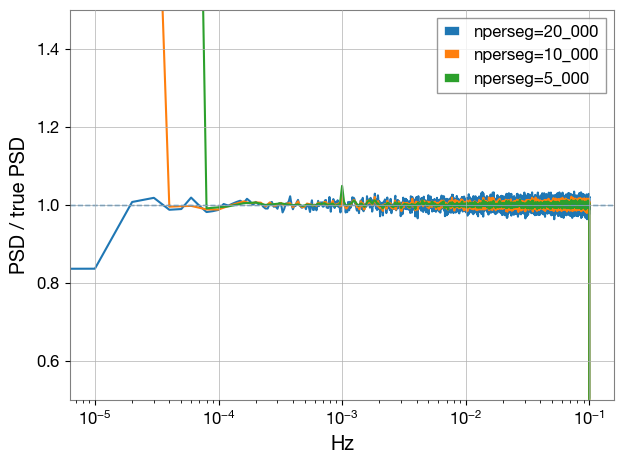

In [42]:
def pick_true_on_coarse(psd_true, nperseg_fine, nperseg_coarse):
    if nperseg_fine % nperseg_coarse != 0:
        raise ValueError(f"{nperseg_coarse} does not divide {nperseg_fine}")
    stride = nperseg_fine // nperseg_coarse
    len_fine = len(psd_true)
    expected_len = nperseg_coarse // 2 + 1
    idx = np.arange(expected_len, dtype=int) * stride
    return psd_true[idx], idx

nperseg_fine = 20_000
nperseg_1    = 20_000
nperseg_2    = 10_000
nperseg_3    =  5_000

t1, idx1 = pick_true_on_coarse(psd_true, nperseg_fine, nperseg_1)
t2, idx2 = pick_true_on_coarse(psd_true, nperseg_fine, nperseg_2)
t3, idx3 = pick_true_on_coarse(psd_true, nperseg_fine, nperseg_3)

plt.semilogx(f_1, psd_1 / t1, label='nperseg=20_000')
plt.semilogx(f_2, psd_2 / t2, label='nperseg=10_000')
plt.semilogx(f_3, psd_3 / t3, label='nperseg=5_000')
plt.axhline(1.0, ls='--', lw=1)
plt.ylim(0.5,1.5)
plt.xlabel('Hz'); plt.ylabel('PSD / true PSD'); plt.legend(); plt.tight_layout(); plt.show()

ValueError: operands could not be broadcast together with shapes (5001,) (10001,) 

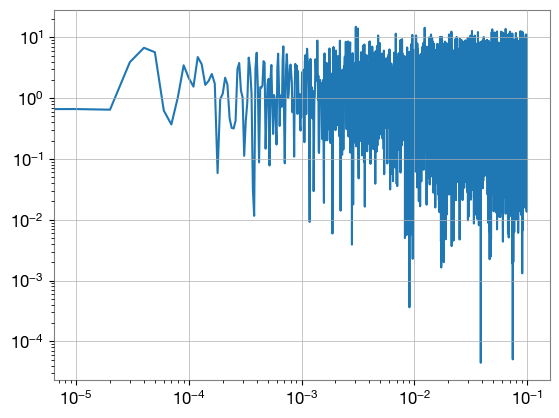

In [ ]:
f_1, psd_1, _, _ = wosa(x_time, fs=fs, nperseg=20_000)
f_2, psd_2, _, _ = wosa(x_time, fs=fs, nperseg=10_000)
f_3, psd_3, _, _ = wosa(x_time, fs=fs, nperseg=5_000)

plt.loglog(f_1, psd_1 / psd_true, label='20_000')
plt.loglog(f_2, psd_2 / psd_true, label='10_000')
plt.loglog(f_3, psd_3 / psd_true, label='5_000')
plt.legend(); plt.xlabel('Hz'); plt.ylabel('PSD'); plt.show()
